# Paquetes

In [2]:
import pygmt
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import verde as vd
import matplotlib.pyplot as plt

# Probando pygmt

In [3]:
pygmt.show_versions()

PyGMT information:
  version: v0.18.0
System information:
  python: 3.13.11 | packaged by conda-forge | (main, Jan 27 2026, 00:06:37) [Clang 19.1.7 ]
  executable: /opt/miniconda3/envs/geo/bin/python
  machine: macOS-26.2-arm64-arm-64bit-Mach-O
Dependency information:
  numpy: 2.3.5
  pandas: 3.0.0
  xarray: 2026.1.0
  packaging: 26.0
  contextily: 1.7.0
  geopandas: 1.1.2
  IPython: 8.18.1
  pyarrow: 23.0.0
  rioxarray: 0.21.0
  gdal: 3.12.1
  ghostscript: 10.06.0
GMT library information:
  version: 6.6.0
  padding: 2
  share dir: /opt/miniconda3/envs/geo/share/gmt
  plugin dir: /opt/miniconda3/envs/geo/lib/gmt/plugins
  library path: /opt/miniconda3/envs/geo/lib/libgmt.dylib
  cores: 8
  grid layout: rows
  image layout: 
  binary version: 6.6.0


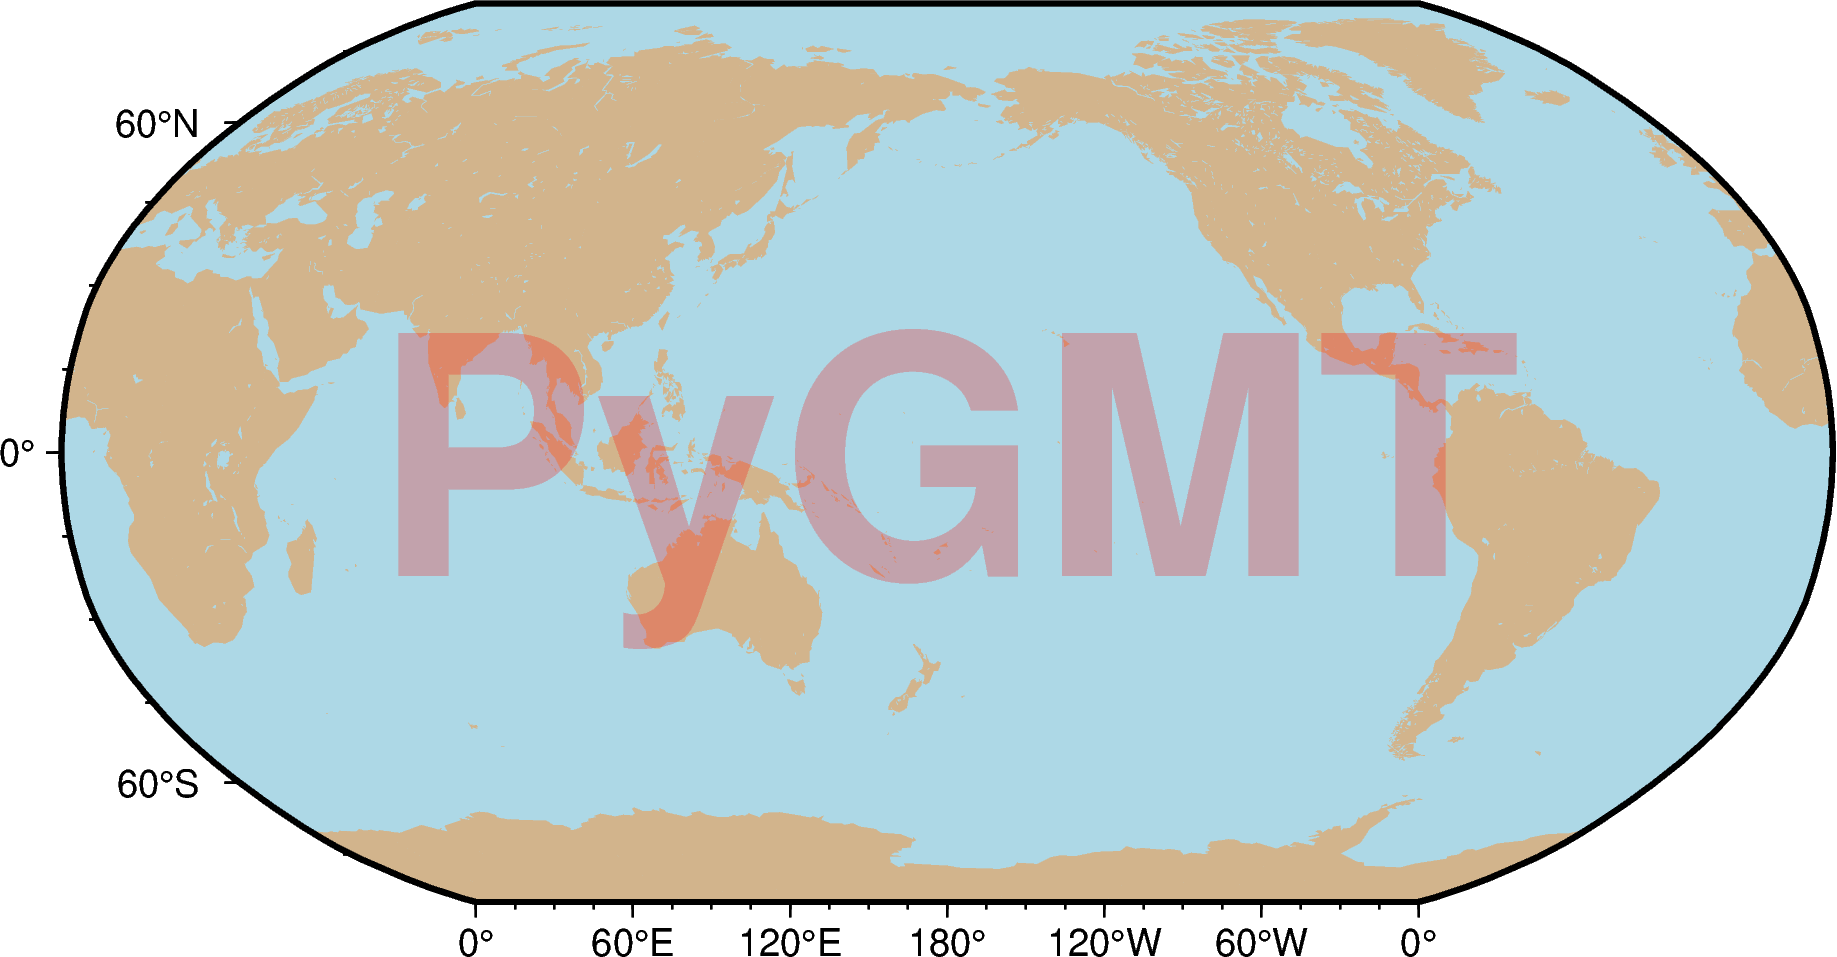

In [6]:
fig = pygmt.Figure()
fig.coast(projection="N15c", region="g", frame=True, land="tan", water="lightblue")
fig.text(position="MC", text="PyGMT", font="80p,Helvetica-Bold,red@75")
fig.show(method='notebook')  # Use method='external' to open in an external viewer

PyGMT info:
- [intro](https://www.pygmt.org/latest/intro/index.html)
- [tutoriales](https://www.pygmt.org/latest/tutorials/index.html)
- [galeria](https://www.pygmt.org/latest/gallery/index.html)


Paletas de colores:
- [gmt](https://docs.generic-mapping-tools.org/6.5/reference/cpts.html#cpt-files-a)
- [cpt-city](http://seaviewsensing.com/pub/cpt-city/)
- [Scientific colour maps](https://www.fabiocrameri.ch/colourmaps/)


# Datos vectoriales

## Sin CRS

### Leer datos

In [10]:
datos = pd.read_csv("../data/BroomsBarn3.csv")
datos

,x,y,K,pH,P
0,40,960,26,7.2,5.5
1,40,1000,22,7.2,5.2
2,40,1040,18,6.8,2.6
3,40,1080,19,6.4,1.3
4,40,1120,26,6.1,1.3
...,...,...,...,...,...
428,720,960,29,8.1,6.8
429,720,1000,29,7.9,9.0
430,720,1040,23,7.9,7.5
431,720,1080,20,8.0,6.6


### Convertir a espaciales

In [11]:
x_coord = 'x' # nombre de la columna con coordenadas X
y_coord = 'y' # nombre de la columna con coordenadas Y

datos_sf = gpd.GeoDataFrame(
    datos, geometry=gpd.points_from_xy(datos[x_coord], datos[y_coord]), crs=None
)

### Poligono exterior

In [69]:
outline = datos_sf.union_all().convex_hull
outline_sf = gpd.GeoDataFrame(geometry=[outline], crs=datos_sf.crs)

### Definir region y proyeccion

Como los datos no tienen un CRS hay que calcular la proyeccion para que las escalas de los ejes sean las mismas.

In [156]:
pygmt.info(data=datos[[x_coord, y_coord]], spacing=1)

array([  40.,  720.,   40., 1240.])

In [141]:
region_vd = vd.get_region([datos.x, datos.y])
print(region_vd)

(np.int64(40), np.int64(720), np.int64(40), np.int64(1240))


In [12]:
pad_frac = 0.03                           # 3% padding
xmin, ymin, xmax, ymax = datos_sf.total_bounds
padx = pad_frac * (xmax - xmin)
pady = pad_frac * (ymax - ymin)

region = [xmin, xmax, ymin, ymax]
region_pad = [xmin - padx, xmax + padx, ymin - pady, ymax + pady]

xspan = region[1] - region[0]
yspan = region[3] - region[2]

width_cm = 6                        # choose canvas width
height_cm = width_cm * (yspan / xspan)  # set height so cm/unit is equal

proj = f"X{width_cm}c/{height_cm}c"     # linear projection with equal x/y scale


### Mapa

/opt/miniconda3/envs/geo/lib/python3.13/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


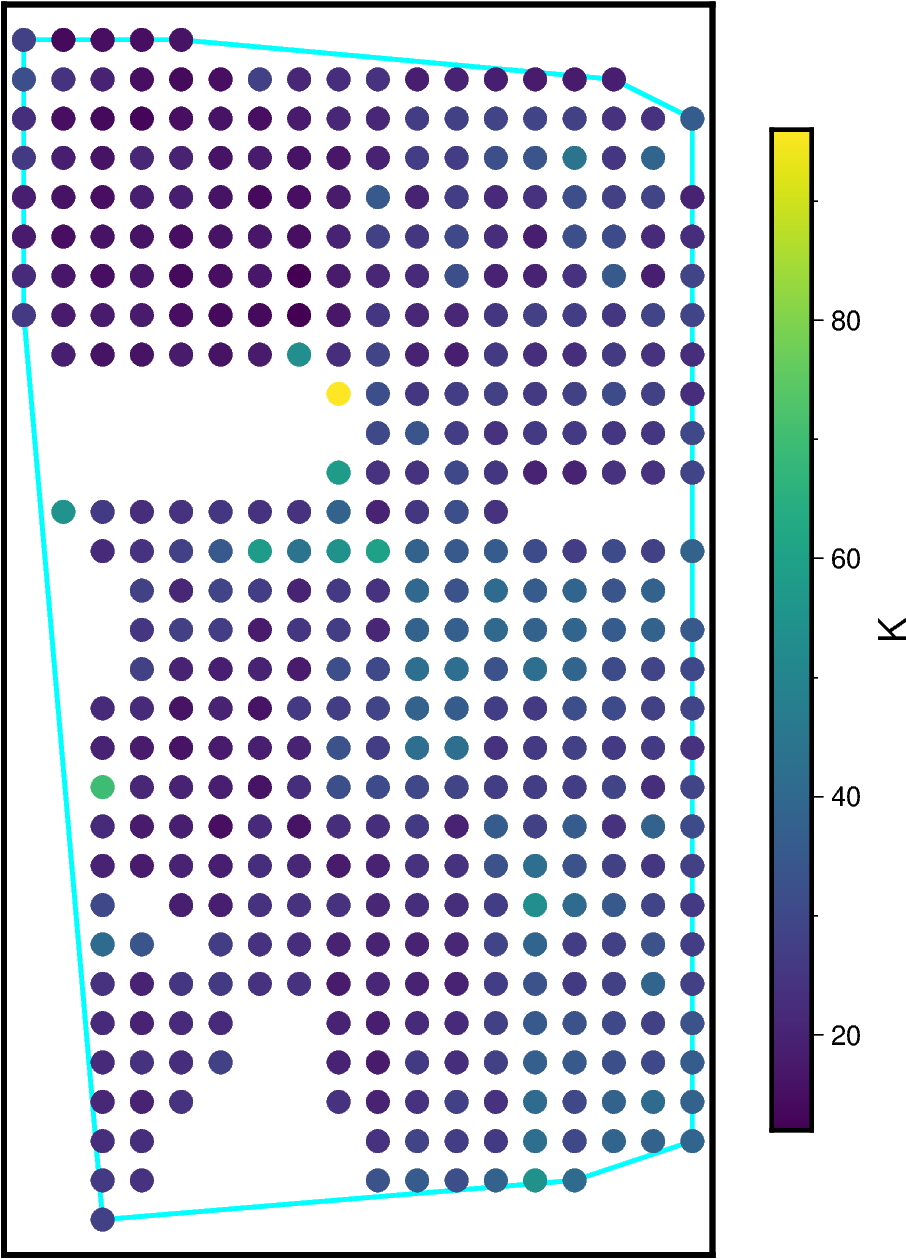

In [78]:
fig = pygmt.Figure()

fig.basemap(
    region=region_pad, 
    projection=proj, 
    frame="WSen"
    # frame=True
    )

pygmt.makecpt(
    cmap="viridis", 
    series=[datos['K'].min(), datos['K'].max()]
    )

fig.colorbar(frame="x+lK", position="JRM+o0.5c/0c+v")

fig.plot(
    data=outline_sf,
    pen="1p,cyan"
)

fig.plot(
    x=datos_sf.geometry.x, 
    y=datos_sf.geometry.y,
    style="c0.2c", 
    fill=datos_sf['K'],
    cmap=True
    )

fig.show(method='notebook')

## Con CRS

### Leer datos

In [4]:
datos = pd.read_csv("../data/muestras.csv").dropna()
datos

,x,y,muestra,litologia,unidad,gamma_t,gamma_d,gamma_sat,w,gs,...,e,sr,finos,arena,grava,ll,lp,ip,simbolo,sucs
0,371390.0,1127779.0,AGG1-1,Areniscas finas/Lutitas,Mb. Zapotal,14.14,11.87,17.15,19.12,2.62,...,1.17,42.99,78.17,21.83,0.00,0.00,0.00,0.00,CL-ML,Arcilla limosa con arena
1,370408.0,1127800.0,AGG1-2,Areniscas finas/Lutitas,Mb. Zapotal,17.34,13.40,18.04,29.38,2.59,...,0.90,84.95,97.73,2.11,0.15,46.22,20.47,25.75,CL,Arcilla delgada
2,372746.0,1130548.0,AGG1-3,Conglomerados,Mb. Cerco de Piedra,17.81,13.61,18.28,30.88,2.65,...,0.91,89.89,82.72,15.56,1.72,39.57,23.82,15.75,CL,Arcilla delgada con arena
3,371067.0,1131027.0,AGG1-4,Areniscas finas/Lutitas,Mb. Zapotal,19.50,16.37,19.66,19.12,2.51,...,0.50,95.19,87.84,6.73,5.43,59.99,23.82,36.16,CH,Arcilla gruesa
4,369546.0,1132847.0,AGG1-5,Areniscas finas/Lutitas,Mb. Zapotal,15.93,12.19,16.92,30.65,2.40,...,0.93,79.01,80.99,9.06,9.95,54.25,28.27,25.98,CH,Arcilla gruesa con grava
5,369530.0,1133334.0,AGG1-6,Areniscas finas/Lutitas,Mb. Zapotal,18.53,13.89,17.93,33.44,2.41,...,0.70,114.71,95.61,4.39,0.00,62.97,56.03,6.94,MH,Limo elástico
6,372488.0,1134586.0,AGG1-7,Areniscas finas/Lutitas,Mb. Zapotal,16.04,12.39,17.38,29.48,2.57,...,1.04,73.19,93.53,6.47,0.00,61.14,44.14,17.00,MH,Limo elástico
7,372474.0,1134585.0,AGG1-8,Areniscas finas/Lutitas,Mb. Zapotal,17.49,12.78,17.69,36.88,2.61,...,1.00,95.89,90.20,9.60,0.20,58.60,28.85,29.75,CH,Arcilla gruesa
8,375732.0,1133978.0,AGG1-9,Areniscas finas/Lutitas,Mb. Zapotal,14.88,11.19,16.32,33.03,2.39,...,1.10,72.02,65.89,17.83,16.27,65.43,33.89,31.53,MH,Limo elástico arenoso con grava
9,375732.0,1133978.0,AGG1-10,Areniscas finas/Lutitas,Mb. Zapotal,16.63,11.51,16.77,44.51,2.53,...,1.16,97.35,95.38,4.08,0.54,56.90,31.54,25.36,MH,Limo elástico


In [125]:
# from pyproj import datadir
# datadir.set_data_dir("/opt/miniconda3/envs/geo/share/proj")

### Convertir a espaciales

Se asigna el CRS respectivo.

In [5]:
x_coord = 'x' # nombre de la columna con coordenadas X
y_coord = 'y' # nombre de la columna con coordenadas Y

datos_sf = gpd.GeoDataFrame(
    datos, geometry=gpd.points_from_xy(datos[x_coord], datos[y_coord])
).set_crs(epsg=5367)

### Definir region

In [6]:
pad_frac = 0.03                           # 3% padding
xmin, ymin, xmax, ymax = datos_sf.total_bounds
padx = pad_frac * (xmax - xmin)
pady = pad_frac * (ymax - ymin)

region = [xmin - padx, xmax + padx, ymin - pady, ymax + pady]

### Mapa

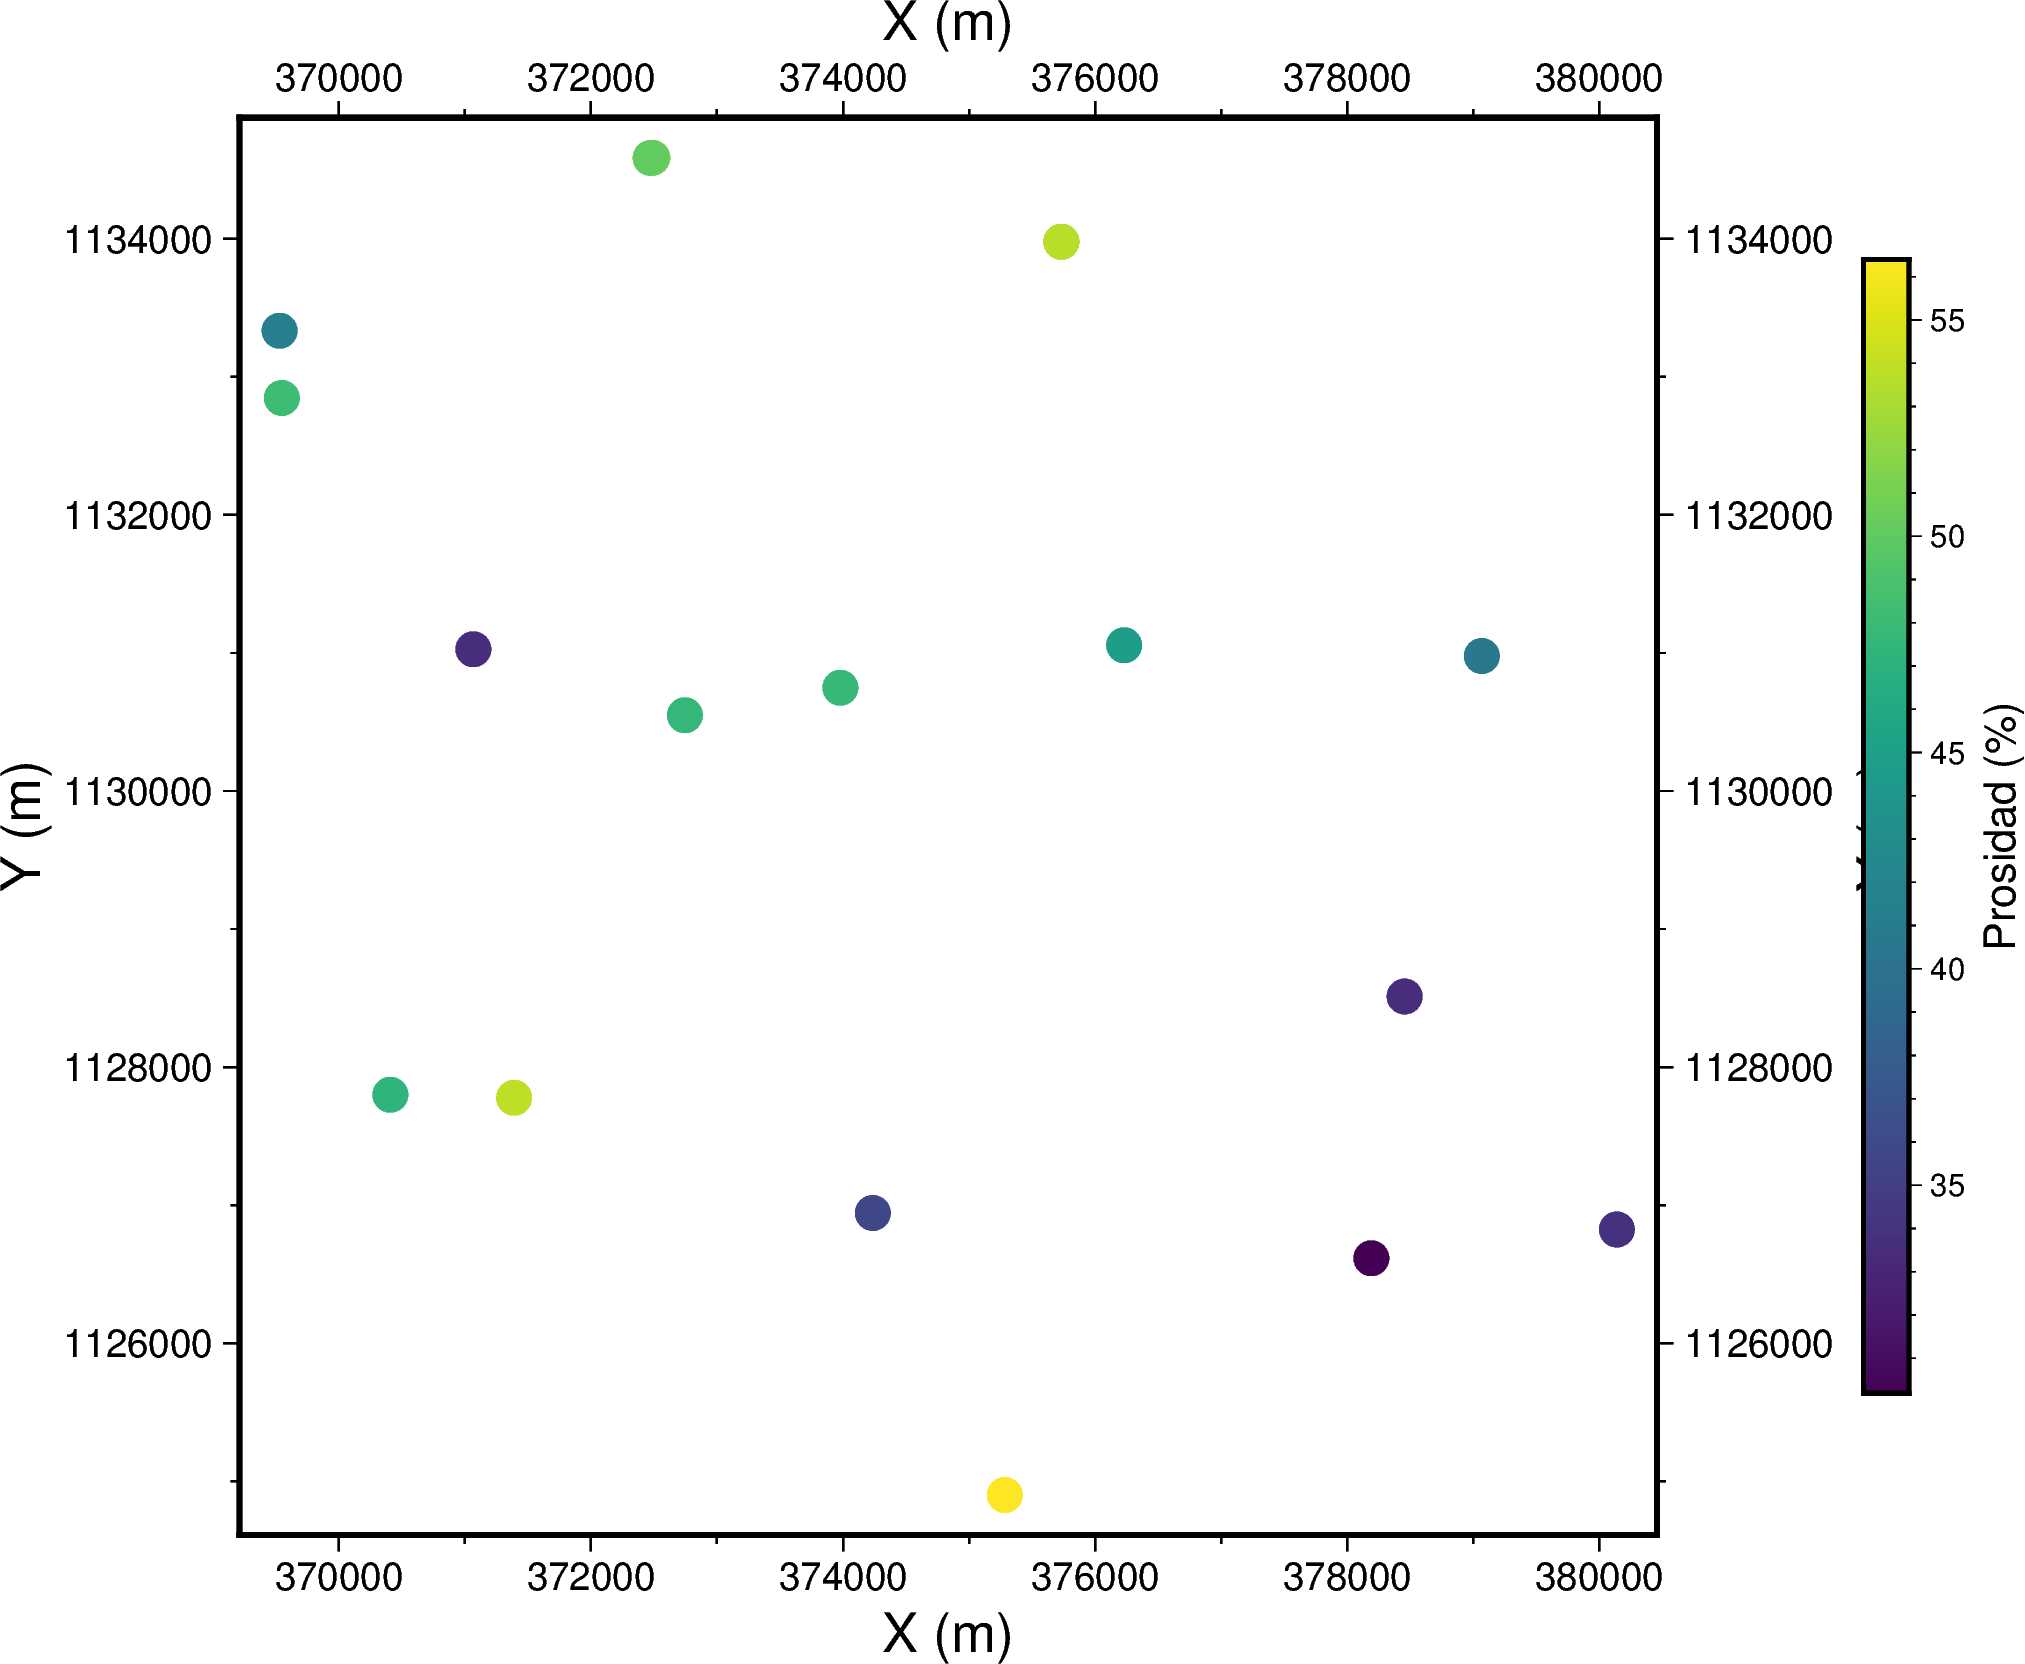

In [13]:
fig = pygmt.Figure()

fig.basemap(
    region=region, 
    projection="X12c", 
    frame=["WSNE", "x+lX (m)", "y+lY (m)"]
    )

pygmt.makecpt(
    cmap="viridis", 
    series=[datos['n'].min(), datos['n'].max()]
    )

fig.colorbar(frame="x+lProsidad (%)", position="JRM+o1.75c/0c+v")

fig.plot(
    x=datos_sf.geometry.x, 
    y=datos_sf.geometry.y,
    style="c0.3c", 
    fill=datos_sf['n'],
    cmap=True
    )

fig.show(method='notebook')

# Datos raster

## Con CRS

### Leer datos

In [227]:
grd = xr.load_dataset("../data/pacifico.tif")
grd

<xarray.Dataset> Size: 365kB
Dimensions:      (band: 1, x: 300, y: 300)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 2kB -87.98 -87.97 -87.95 ... -83.05 -83.03 -83.02
  * y            (y) float64 2kB 9.983 9.967 9.95 9.934 ... 5.05 5.033 5.017
    spatial_ref  int64 8B 0
Data variables:
    band_data    (band, y, x) float32 360kB -3.183e+03 -3.187e+03 ... -3.314e+03

### Información del grid

In [216]:
print(pygmt.grdinfo(grid=grd.band_data))

/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: Title: Grid imported via GDAL
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: Command: 
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: Remark: 
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: Pixel node registration used [Geographic grid]
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: Grid file format: gd = Import/export through GDAL
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: x_min: -87.9916666667 x_max: -83.0083333333 x_inc: 0.0166111111111 name: x n_columns: 300
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: y_min: 5.00833333333 y_max: 9.99166666667 y_inc: 0.0166111111111 name: y n_rows: 300
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: v_min: -4770 v_max: 3276 name: z
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-yfayn3q1.tif: scale_factor: 1 add_offse

/opt/miniconda3/envs/geo/lib/python3.13/site-packages/pygmt/helpers/decorators.py:833: RuntimeWarning: Input image has dtype: float32 which is unsupported, and may result in an incorrect output. Please recast image to a uint8 dtype and/or scale to 0-255 range, e.g. using a histogram equalization function like skimage.exposure.equalize_hist.
  return module_func(*args, **kwargs)


### Mapa basico con xr

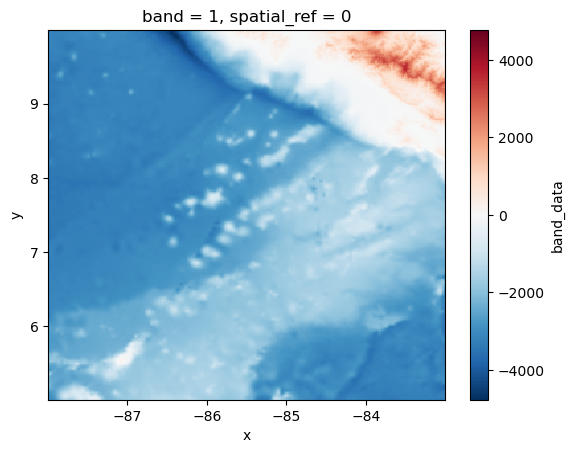

In [84]:
grd.band_data.plot()

### Mapa

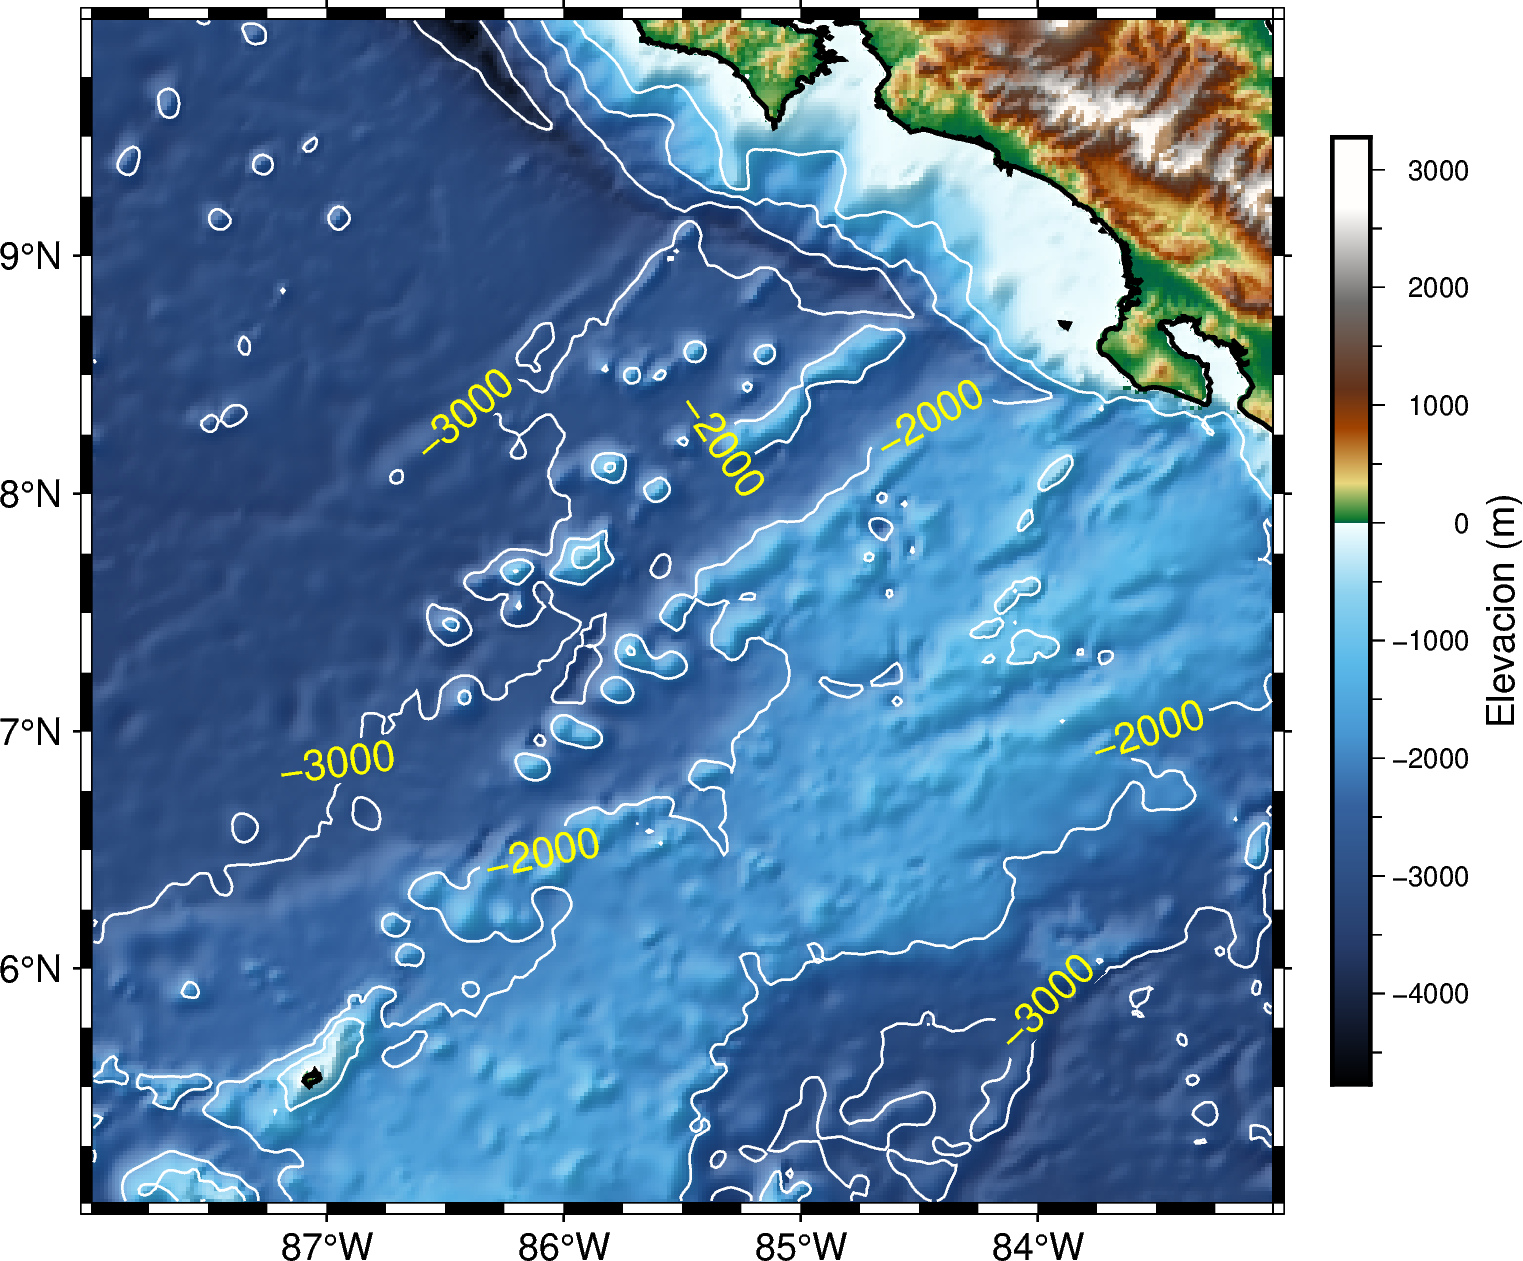

In [236]:
fig = pygmt.Figure()

fig.grdimage(
    grid=grd.band_data, 
    cmap="geo", # "oleron", "reflief", "etopo1"
    projection='M10c', 
    frame=True,
    transparency=0,
    shading="+a-45+nt0.5"
    )

fig.grdcontour(
    grid=grd.band_data,
    annotation="1000+f10p,yellow",
    levels=1000,
    limit=[-4000, 0],
    pen="0.5p,white",
    )

fig.coast(
    shorelines="1/1p,black",
    resolution="h" # ["c", "l", "i", "h", "f"]
    )

fig.colorbar(
    frame=["a1000f500","x+lElevacion (m)"], 
    position="JRM+o0.5c/0c+v"
    )

fig.show(method='notebook')


## Sin CRS

### Leer datos

In [7]:
grd = xr.load_dataset("../figs/krige_pred.tif")
print(grd.data_vars)

Data variables:
    band_data  (band, y, x) float64 187kB 25.27 24.7 23.71 ... 36.13 35.85 35.55


In [8]:
grd = grd.rename_vars(name_dict={"band_data": "K"})
grd

<xarray.Dataset> Size: 190kB
Dimensions:      (band: 1, x: 116, y: 202)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 928B 37.0 43.0 49.0 55.0 ... 715.0 721.0 727.0
  * y            (y) float64 2kB 1.243e+03 1.237e+03 1.231e+03 ... 43.0 37.0
    spatial_ref  int64 8B 0
Data variables:
    K            (band, y, x) float64 187kB 25.27 24.7 23.71 ... 35.85 35.55

In [189]:
print(pygmt.grdinfo(grid=grd.K))

/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: Title: Grid imported via GDAL
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: Command: 
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: Remark: 
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: Pixel node registration used [Cartesian grid]
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: Grid file format: gd = Import/export through GDAL
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: x_min: 34 x_max: 730 x_inc: 6 name: x n_columns: 116
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: y_min: 34 y_max: 1246 y_inc: 6 name: y n_rows: 202
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: v_min: 14.7601853911 v_max: 40.1582188857 name: z
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/pygmt-tlao_2k7.tif: scale_factor: 1 add_offset: 0
/var/folders/k3/hwk6st_j5w390nvxdc_zrd_m0000gn/T/p

In [190]:
grd_df = pygmt.grd2xyz(grd.K, output_type="pandas")
grd_df.columns = ["x", "y", "z"]
grd_df

,x,y,z
0,37.0,1243.0,25.274210
1,43.0,1243.0,24.698219
2,49.0,1243.0,23.708290
3,55.0,1243.0,22.719124
4,61.0,1243.0,21.735752
...,...,...,...
23427,703.0,37.0,36.669773
23428,709.0,37.0,36.406868
23429,715.0,37.0,36.131126
23430,721.0,37.0,35.845165


In [ ]:
# region = pygmt.info(data=grd_df[["x", "y"]], spacing=1)
# print(region)

[  37.  727.   37. 1243.]


### Mapa

/opt/miniconda3/envs/geo/lib/python3.13/site-packages/pygmt/helpers/decorators.py:833: RuntimeWarning: Input image has dtype: float64 which is unsupported, and may result in an incorrect output. Please recast image to a uint8 dtype and/or scale to 0-255 range, e.g. using a histogram equalization function like skimage.exposure.equalize_hist.
  return module_func(*args, **kwargs)


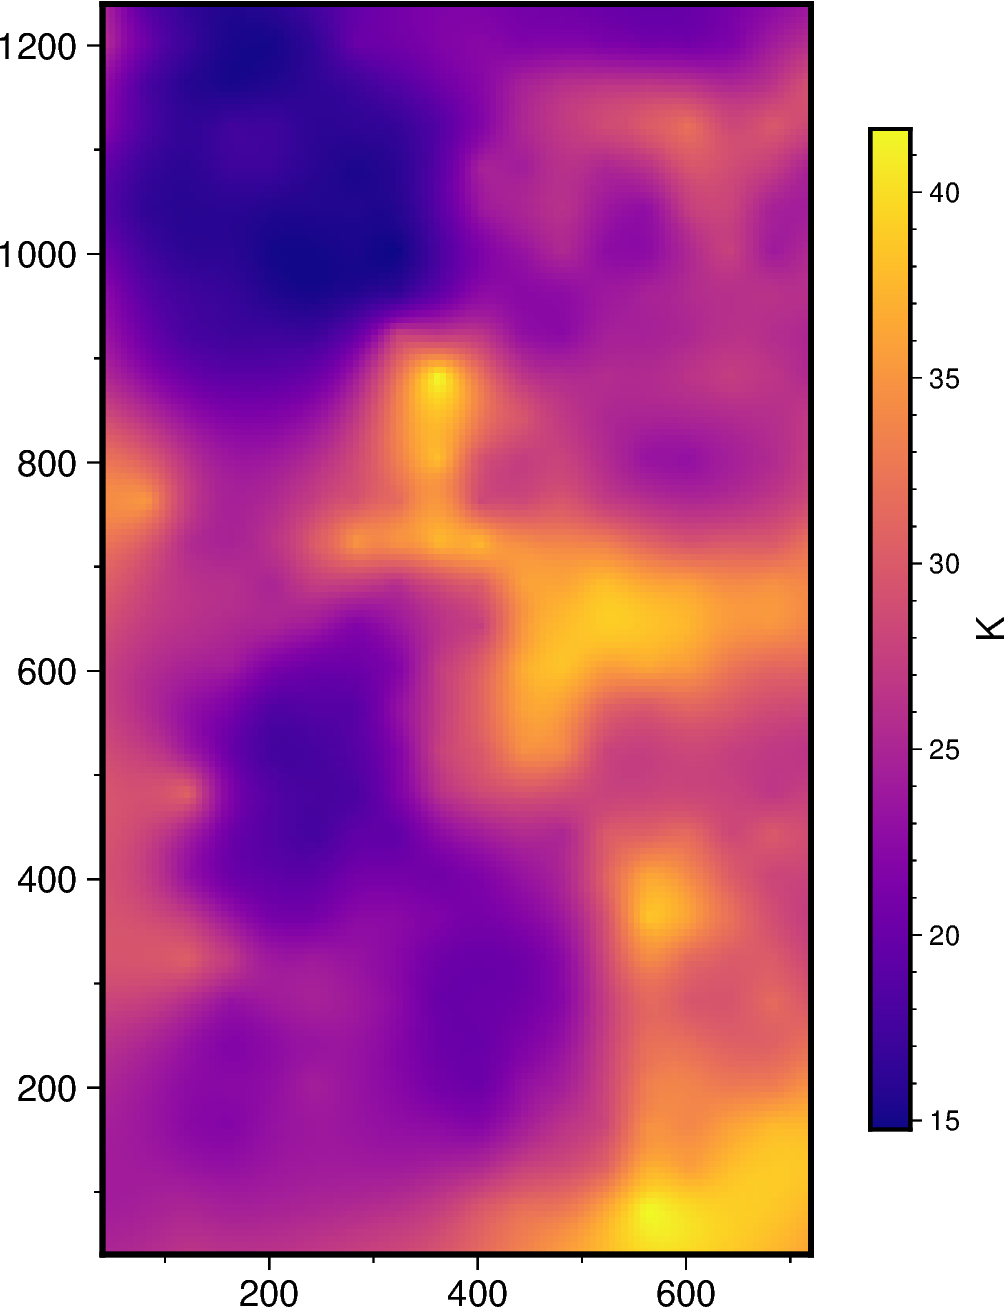

In [13]:
fig = pygmt.Figure()

fig.grdimage(
    grid=grd.K, 
    cmap="plasma", 
    region=region,
    projection=proj, 
    frame=True,
    # shading=True,
    )

fig.colorbar(frame="x+lK", position="JRM+o0.5c/0c+v")

fig.show(method='notebook')

## Imagen satelital

### Leer datos

In [220]:
data = rxr.open_rasterio("../data/imagen_satelite.tif")
# data.load()  # cargar datos en memoria
data

<xarray.DataArray (band: 6, y: 352, x: 349)> Size: 3MB
[737088 values with dtype=float32]
Coordinates:
  * band         (band) int64 48B 1 2 3 4 5 6
  * y            (y) float64 3kB 9.121e+06 9.121e+06 ... 9.111e+06 9.111e+06
  * x            (x) float64 3kB 2.888e+05 2.888e+05 ... 2.987e+05 2.987e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  255
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  47
    STATISTICS_STDDEV:   nan
    _FillValue:          -3.4e+38
    scale_factor:        1.0
    add_offset:          0.0

### Seleccionar bandas

In [221]:
img = data.sel(band=[3,2,1])  # seleccionar bandas RGB 
img

<xarray.DataArray (band: 3, y: 352, x: 349)> Size: 1MB
[368544 values with dtype=float32]
Coordinates:
  * band         (band) int64 24B 3 2 1
  * y            (y) float64 3kB 9.121e+06 9.121e+06 ... 9.111e+06 9.111e+06
  * x            (x) float64 3kB 2.888e+05 2.888e+05 ... 2.987e+05 2.987e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  255
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  47
    STATISTICS_STDDEV:   nan
    _FillValue:          -3.4e+38
    scale_factor:        1.0
    add_offset:          0.0

### Corregir NaN/nodata

In [222]:
# obtener nodata (si existe) y cambia a NaN
nodata = img.attrs.get("_FillValue", None)
if nodata is not None:
    img = img.where(img != nodata)

# opcional: rescala a [0, 255] si hay valores fuera de este rango
img = img.clip(0, 255)  # ajustar según el rango de valores de la imagen

# reemplazar NaNs con un valor de fondo seguro y convertir a uint8
img = img.fillna(0).astype("uint8")

# remueve metadatos nodata para que rioxarray no intente convertir el antiguo nodata
img.attrs.pop("_FillValue", None)

img

<xarray.DataArray (band: 3, y: 352, x: 349)> Size: 369kB
array([[[ 46,  49,  45, ..., 130, 171, 162],
        [ 55,  51,  41, ..., 163, 163, 137],
        [ 48,  42,  42, ..., 156, 129,  98],
        ...,
        [ 51,  42,  35, ...,  63,  63,  61],
        [ 48,  44,  53, ...,  63,  63,  62],
        [ 40,  55,  61, ...,  64,  64,  64]],

       [[ 56,  57,  52, ..., 109, 151, 140],
        [ 63,  56,  48, ..., 139, 141, 121],
        [ 56,  53,  52, ..., 137, 108,  94],
        ...,
        [ 54,  56,  48, ...,  92,  90,  89],
        [ 51,  53,  54, ...,  90,  90,  89],
        [ 46,  58,  64, ...,  89,  90,  91]],

       [[ 69,  69,  63, ..., 117, 157, 151],
        [ 74,  68,  59, ..., 144, 152, 127],
        [ 68,  64,  61, ..., 145, 118, 101],
        ...,
        [ 68,  66,  62, ...,  97,  97,  98],
        [ 67,  68,  71, ...,  97,  97,  98],
        [ 65,  74,  76, ...,  98, 100, 100]]], shape=(3, 352, 349), dtype=uint8)
Coordinates:
  * band         (band) int64 24B 3 2 1
  * y            (y) float64 3kB 9.121e+06 9.121e+06 ... 9.111e+06 9.111e+06
  * x            (x) float64 3kB 2.888e+05 2.888e+05 ... 2.987e+05 2.987e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  255
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  47
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

### Imagen

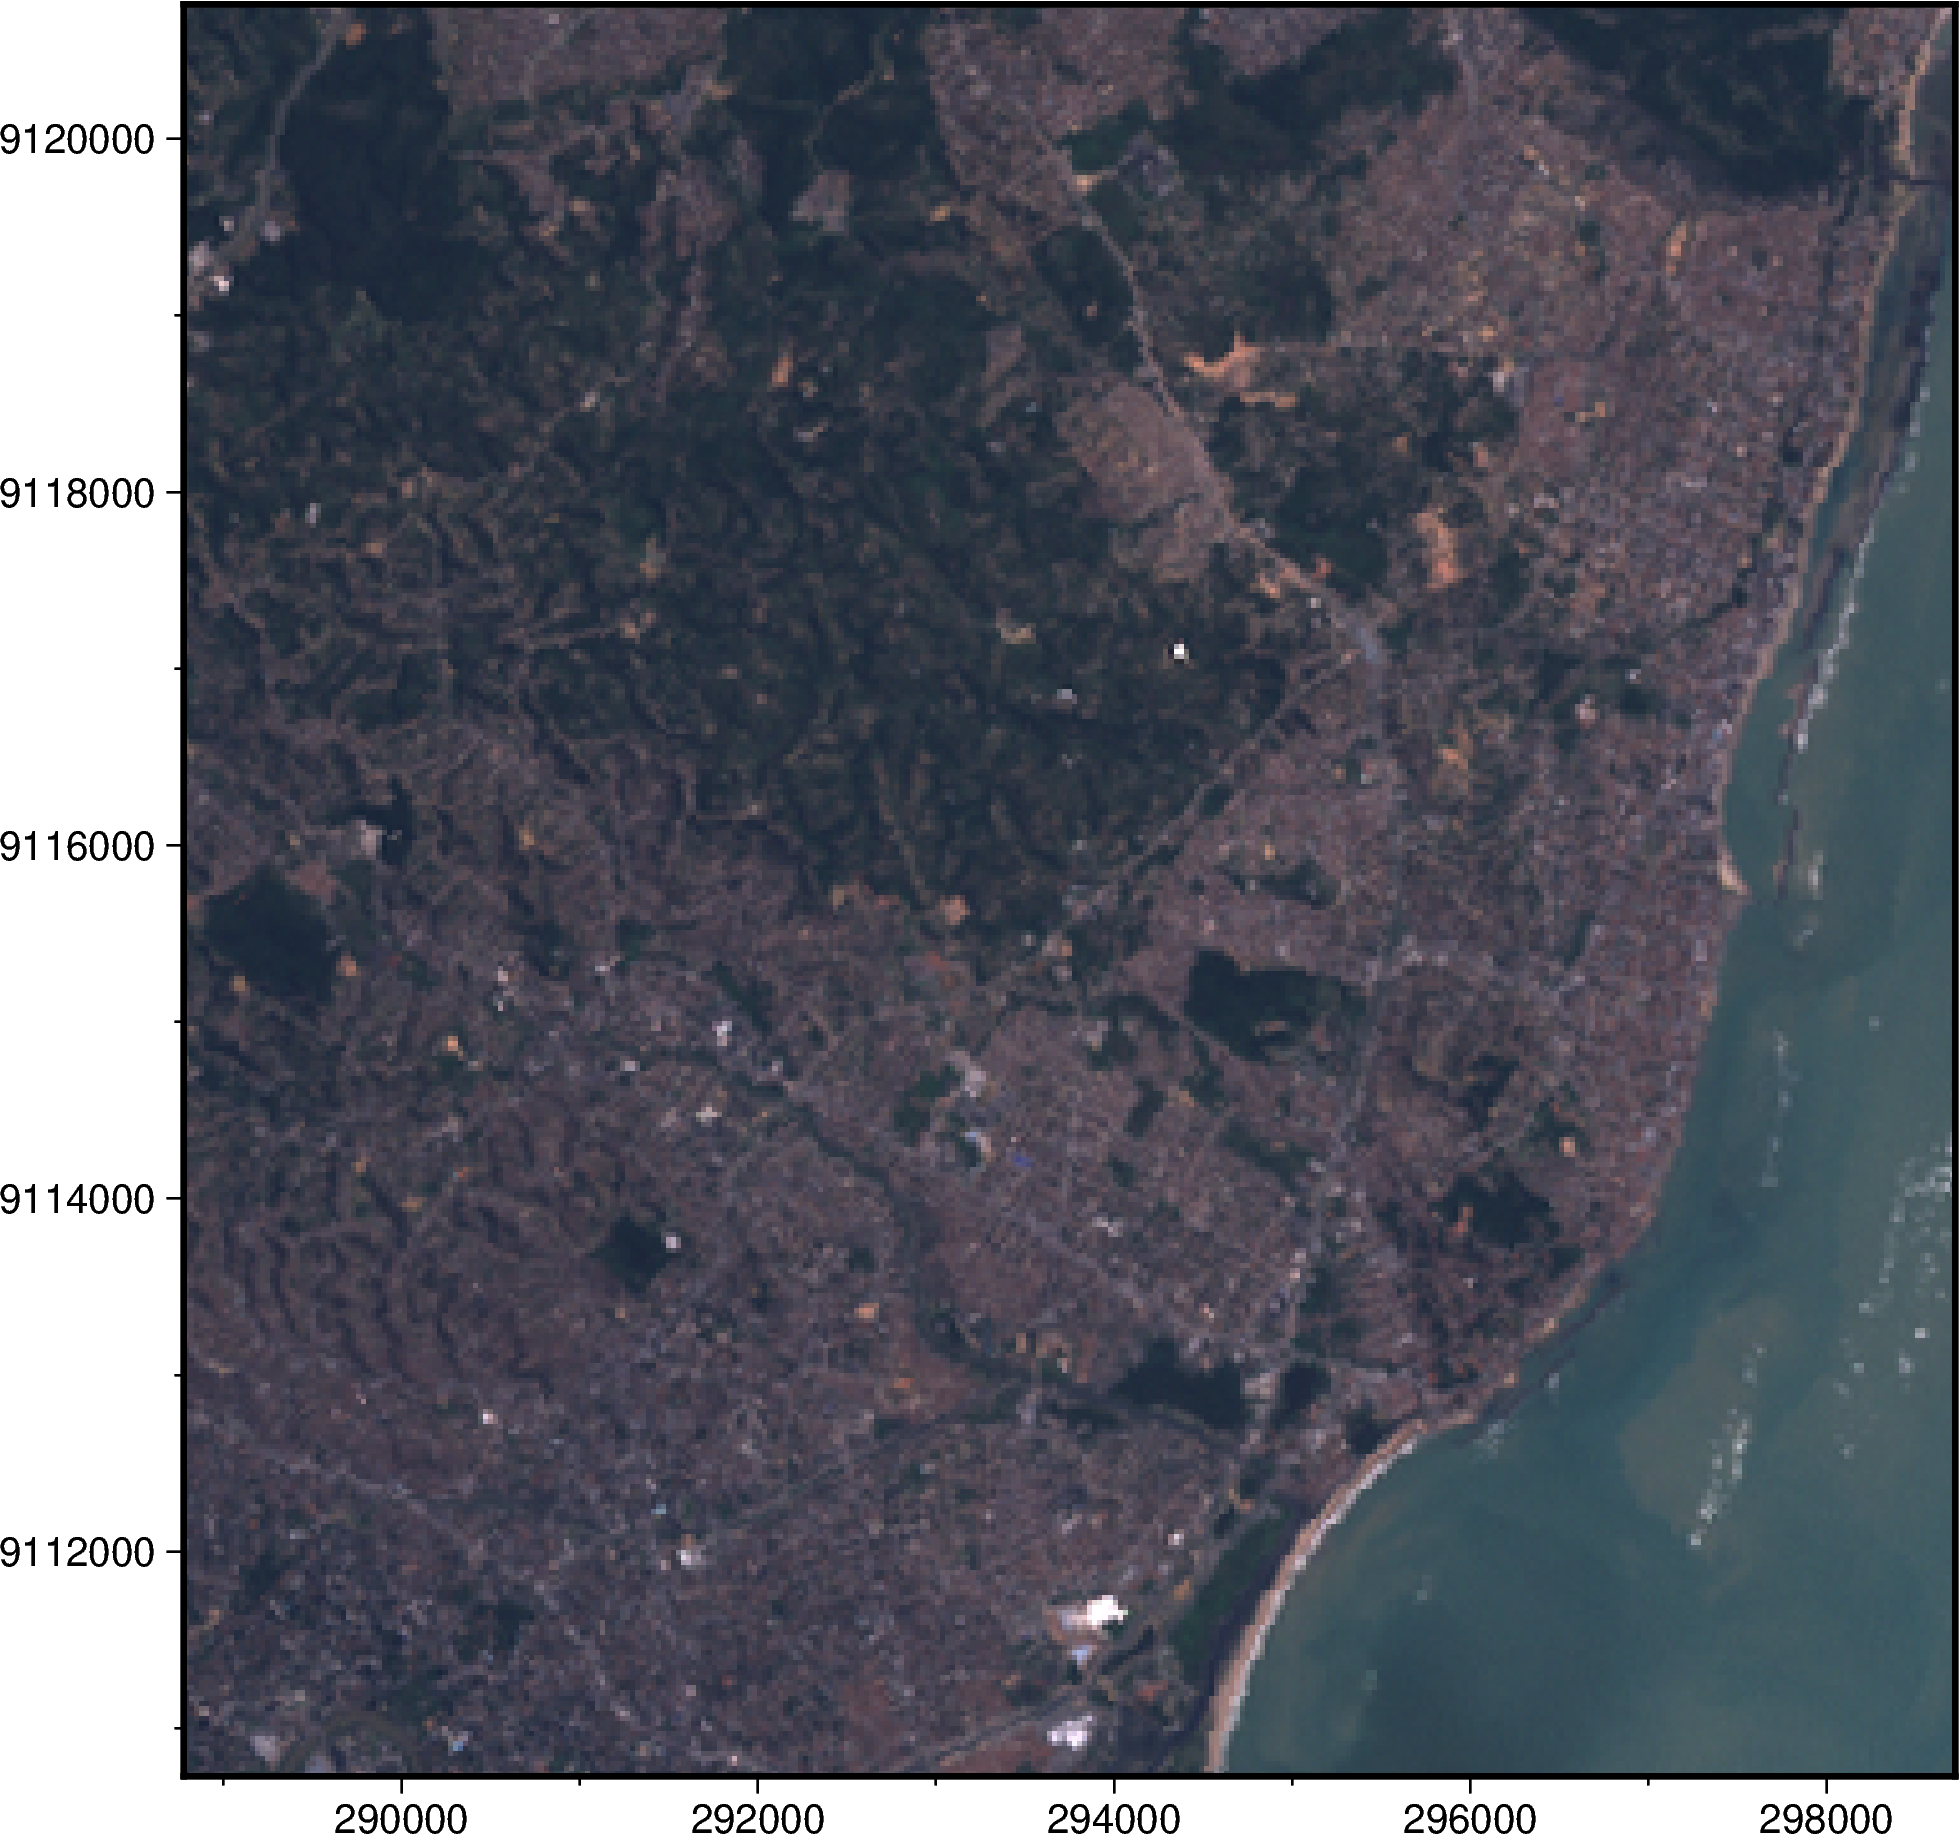

In [223]:
fig = pygmt.Figure()

fig.grdimage(
    grid=img,
    frame=True
)

fig.show(method='notebook')

### Imagen con matplotlib

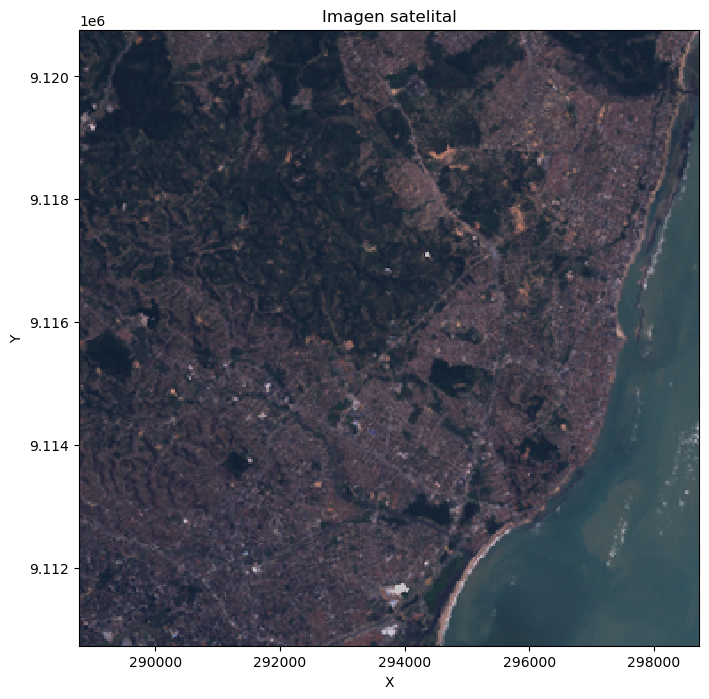

In [ ]:
plt.figure(figsize=(8, 8))
img.plot.imshow(vmin=0, vmax=255)
plt.title("Imagen satelital")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()